# Decomposing Toxic Language

**Research question.** How do lexical signals, structural writing signals, and
their combination participate in classifying online toxicity subtypes?

This notebook uses the Jigsaw Toxic
Comment Classification Challenge training data and compares three logistic
regression baselines for each toxicity label:

1. Lexical-only features from TF-IDF.
2. Structural-only features such as length, capitalization, punctuation, and
   repetition.
3. Combined lexical plus structural features.


# **Data Import**

In [ ]:
#Import Dataset
import os
import re

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

from scipy.sparse import hstack

In [ ]:
#Log into Kaggle
import kagglehub
kagglehub.login()

#Download the files
path = kagglehub.competition_download('jigsaw-toxic-comment-classification-challenge')
print("Path to competition files:", path)

Path to competition files: /root/.cache/kagglehub/competitions/jigsaw-toxic-comment-classification-challenge
Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
#formatting now display full comment text
pd.set_option('display.max_colwidth', None)

In [ ]:
#Mount to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Access the files and read the train data
train_path = os.path.join(path, "train.csv.zip")
data = pd.read_csv(train_path)
#From now on, we can just read the file locally instead of constantly getting it from Kaggle
data.to_csv("/content/drive/MyDrive/Programming Tools for the Data Scientist/data.csv", index=False)

data.head()

In [ ]:
# Alternative: Directly load data from Kaggle (without saving to Google Drive)
# Use this if you don't want to save to Google Drive or are facing issues.
# Make sure to comment out the Google Drive saving part in the cell above if using this.

train_path_kaggle = os.path.join(path, "train.csv.zip")
data = pd.read_csv(train_path_kaggle)
data.head()

In [ ]:
# Look at how many comments are classified as each subtype
label_cols = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate",
]

data[label_cols].sum().sort_values(ascending=False)

,0
toxic,15294
obscene,8449
insult,7877
severe_toxic,1595
identity_hate,1405
threat,478


 # **Cleaning & Preprocessing**

In [ ]:
try:
    data = pd.read_csv("/content/drive/MyDrive/Programming Tools for the Data Scientist/data.csv")
    print("Loaded saved local copy.")
except FileNotFoundError:
    print("Local file not found. Change the path if it is saved locally, or retrieve the data using Kaggle.")

In [ ]:
# Remove new line, tab, repeating spaces
label_cols = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate",
]

def clean_text(text):
    text = text.replace("\n", " ")        # remove newlines
    text = text.replace("\t", " ")        # remove tabs
    text = re.sub(r"\s+", " ", text)      # remove extra spaces
    return text.strip()

data["clean_text"] = data["comment_text"].apply(clean_text)
data[["comment_text", "clean_text"]]

#I want to remove texts that only have numbers at this point
has_alpha = data["clean_text"].str.contains(r"[A-Za-z]", regex=True)
print("Rows with no letters:", (~has_alpha).sum())
data = data[has_alpha].copy().reset_index(drop=True)

data

Rows with no letters: 7


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,clean_text
0,0000997932d777bf,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",0,0,0,0,0,0,"Explanation Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27"
1,000103f0d9cfb60f,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0,0,0,0,0,0,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)"
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.",0,0,0,0,0,0,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info."
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know.\n\nThere appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up. It's listed in the relevant form eg Wikipedia:Good_article_nominations#Transport """,0,0,0,0,0,0,""" More I can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know. There appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up. It's listed in the relevant form eg Wikipedia:Good_article_nominations#Transport """
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember what page that's on?",0,0,0,0,0,0,"You, sir, are my hero. Any chance you remember what page that's on?"
...,...,...,...,...,...,...,...,...,...
159559,ffe987279560d7ff,""":::::And for the second time of asking, when your view completely contradicts the coverage in reliable sources, why should anyone care what you feel? You can't even give a consistent argument - is the opening only supposed to mention significant aspects, or the """"most significant"""" ones? \n\n""",0,0,0,0,0,0,""":::::And for the second time of asking, when your view completely contradicts the coverage in reliable sources, why should anyone care what you feel? You can't even give a consistent argument - is the opening only supposed to mention significant aspects, or the """"most significant"""" ones? """
159560,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is a horrible thing you put on my talk page. 128.61.19.93,0,0,0,0,0,0,You should be ashamed of yourself That is a horrible thing you put on my talk page. 128.61.19.93
159561,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for prostitution ring. - Crunch Captain.",0,0,0,0,0,0,"Spitzer Umm, theres no actual article for prostitution ring. - Crunch Captain."
159562,fff

In [ ]:
# Quickly look at if there are any bad comments: missing or empty comments
print("Missing comments:", data["clean_text"].isna().sum())

empty_comments = data[
    data["clean_text"].isna() |
    (data["clean_text"].astype(str).str.strip() == "")
]

print("Empty comments:", empty_comments.shape[0])


Missing comments: 0
Empty comments: 0


## Create Structural Features


In [ ]:
def add_structural_features(df):
    data_new = df.copy()
    text = data_new["clean_text"].fillna("").astype(str)

    # Comment Length
    data_new["comment_length"] = text.str.len()

    # Word Count
    data_new["word_count"] = text.apply(lambda x: len(x.split()))

    # Uppercase Ratio
    letter_count = text.apply(lambda x: sum(c.isalpha() for c in x))
    uppercase_count = text.apply(lambda x: sum(c.isupper() for c in x))
    data_new["uppercase_ratio"] = uppercase_count / letter_count.replace(0, np.nan)
    data_new["uppercase_ratio"] = data_new["uppercase_ratio"].fillna(0)

    # Punctuation Count and Ratio
    data_new["punctuation_count"] = text.apply(lambda x: sum(c in "!?.,;:" for c in x))
    data_new["punctuation_ratio"] = data_new["punctuation_count"] / data_new["comment_length"].replace(0, np.nan)
    data_new["punctuation_ratio"] = data_new["punctuation_ratio"].fillna(0)

    # Repetition Counts
    data_new["has_repeated_punctuation"] = text.apply(
        lambda x: int(bool(re.search(r"[!?]{2,}", x)))
    )

    data_new["has_repeated_letters"] = text.apply(
        lambda x: int(bool(re.search(r"([a-zA-Z])\1{2,}", x)))
    )

    data_new["repeated_letter_count"] = text.apply(
        lambda x: len(re.findall(r"([a-zA-Z])\1{2,}", x.lower()))
    )

    data_new["repeated_letter_ratio"] = data_new["repeated_letter_count"] / data_new["comment_length"].replace(0, np.nan)
    data_new["repeated_letter_ratio"] = data_new["repeated_letter_ratio"].fillna(0)

    return data_new

In [ ]:
new_data = add_structural_features(data)
structure_cols = [
    "comment_length",
    "word_count",
    "uppercase_ratio",
    "punctuation_count",
    "punctuation_ratio",
    "has_repeated_punctuation",
    "has_repeated_letters",
    "repeated_letter_count",
    "repeated_letter_ratio",
]

#Verify if there are NaN or infinite numbers
bad_number_mask = (
    new_data[structure_cols].isna().any(axis=1) |
    np.isinf(new_data[structure_cols]).any(axis=1)
)

bad_number_rows = new_data.loc[bad_number_mask, ["clean_text"] + structure_cols]

print("Rows with bad numbers:", bad_number_rows.shape[0])

Rows with bad numbers: 0


In [ ]:
# Check a few miscellaneous

assert "clean_text" in new_data.columns
assert new_data["clean_text"].isna().sum() == 0  # clean_text has no missing values
assert new_data[structure_cols].isna().sum().sum() == 0  # No NaN values
assert np.isfinite(new_data[structure_cols]).all().all()  # No infinite values
assert set(label_cols).issubset(new_data.columns)

print("All checks passed.")

All checks passed.


Dataframes created

```
data        # raw + cleaned text only
new_data    # data + structural features
```

In [ ]:
new_data.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,clean_text,comment_length,word_count,uppercase_ratio,punctuation_count,punctuation_ratio,has_repeated_punctuation,has_repeated_letters,repeated_letter_count,repeated_letter_ratio
0,0000997932d777bf,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",0,0,0,0,0,0,"Explanation Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",264,43,0.083744,7,0.026515,0,0,0,0.0
1,000103f0d9cfb60f,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0,0,0,0,0,0,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",111,17,0.109589,6,0.054054,0,0,0,0.0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.",0,0,0,0,0,0,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.",233,42,0.021505,4,0.017167,0,0,0,0.0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know.\n\nThere appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up. It's listed in the relevant form eg Wikipedia:Good_article_nominations#Transport """,0,0,0,0,0,0,""" More I can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know. There appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up. It's listed in the relevant form eg Wikipedia:Good_article_nominations#Transport """,619,113,0.022634,6,0.009693,0,0,0,0.0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember what page that's on?",0,0,0,0,0,0,"You, sir, are my hero. Any chance you remember what page that's on?",67,13,0.040000,4,0.059701,0,0,0,0.0


# **EDA & Visualization**

In [ ]:
# EDA & Visualization
import matplotlib.pyplot as plt
from collections import Counter

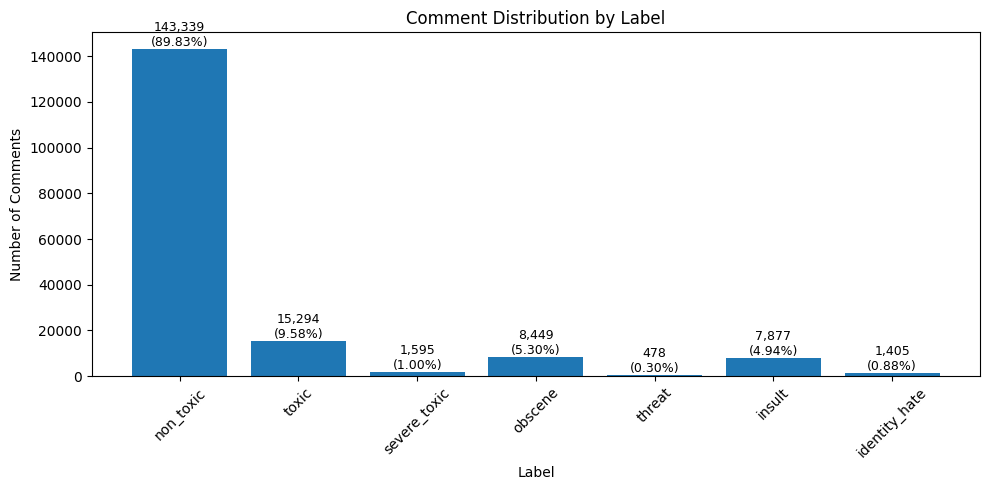

,count,percentage
non_toxic,143339,89.831666
toxic,15294,9.584869
severe_toxic,1595,0.999599
obscene,8449,5.295054
threat,478,0.299566
insult,7877,4.936577
identity_hate,1405,0.880524


In [ ]:
# =========================
# 1. Label Distribution
# =========================

label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

total_comments = data.shape[0]

non_toxic_count = (data[label_cols].sum(axis=1) == 0).sum()

label_counts = data[label_cols].sum()
all_counts = pd.concat([
    pd.Series({"non_toxic": non_toxic_count}),
    label_counts
])

all_percentages = all_counts / total_comments * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(all_counts.index, all_counts.values)

plt.title("Comment Distribution by Label")
plt.xlabel("Label")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)

for bar, pct in zip(bars, all_percentages):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,}\n({pct:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

pd.DataFrame({
    "count": all_counts,
    "percentage": all_percentages
})

- Non-toxic comments make up nearly 90% of the dataset
- Even within the toxic portion, the distribution is uneven — `threat` and `identity_hate` are a small fraction compared to `toxic`, `obscene`  and `insult`
- A model hitting 95% accuracy could essentially be predicting "non-toxic" for almost everything and still look good on paper, a completely useless classifier in practice
- **Modeling consideration:** Use `class_weight='balanced'` to prevent the model from ignoring minority classes, and evaluate using F1-score and PR-AUC rather than accuracy. These metrics will actually reflect how well the model handles rare but important subtypes like `threat` and `identity_hate`

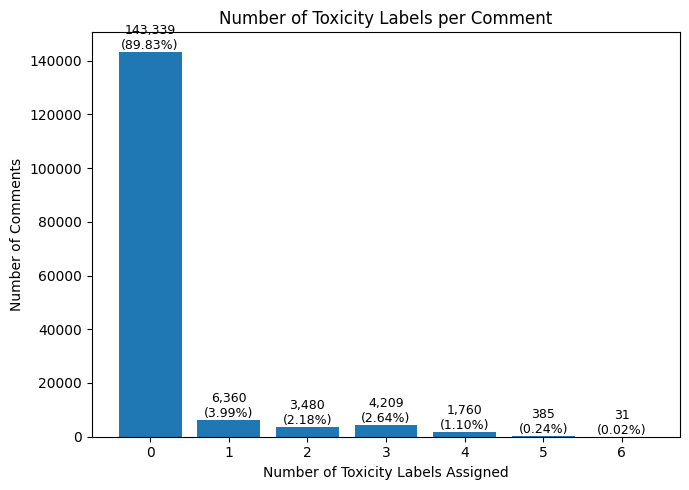

,count,percentage
num_labels,,
0,143339,89.831666
1,6360,3.985861
2,3480,2.180943
3,4209,2.637813
4,1760,1.103006
5,385,0.241282
6,31,0.019428


In [ ]:
# =========================
# 2. Multi-label Overlap
# =========================
data["num_labels"] = data[label_cols].sum(axis=1)

overlap_counts = data["num_labels"].value_counts().sort_index()
overlap_percentages = overlap_counts / total_comments * 100

plt.figure(figsize=(7, 5))
bars = plt.bar(overlap_counts.index.astype(str), overlap_counts.values)

plt.title("Number of Toxicity Labels per Comment")
plt.xlabel("Number of Toxicity Labels Assigned")
plt.ylabel("Number of Comments")

for bar, pct in zip(bars, overlap_percentages):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,}\n({pct:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

pd.DataFrame({
    "count": overlap_counts,
    "percentage": overlap_percentages
})

- Many comments carry more than one toxicity label at the same time, meaning these categories are not mutually exclusive
- A comment can be flagged as both `obscene` and `insult` simultaneously, which makes sense — the two often go hand in hand
- This is not a single-label problem, and treating it as one would be a mistake
- **Modeling consideration:** Each label needs its own binary classifier rather than a single multi-class model — the goal is to predict each subtype independently, not force the comment into one category

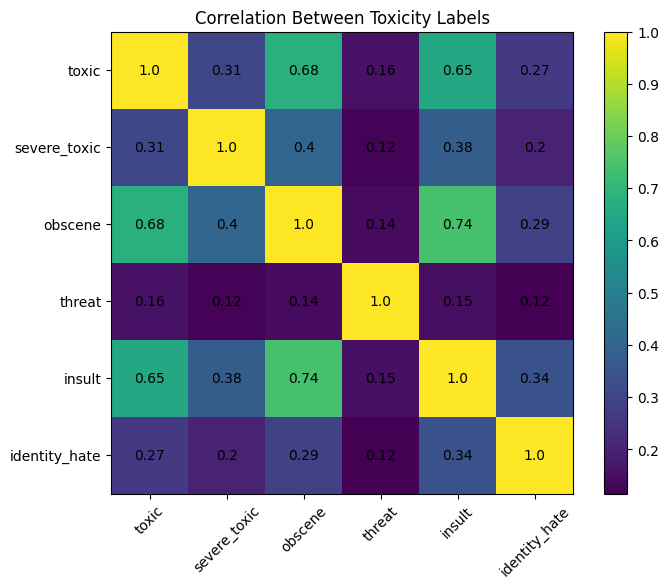

,toxic,severe_toxic,obscene,threat,insult,identity_hate
toxic,1.000000,0.308618,0.676514,0.157058,0.647517,0.266009
severe_toxic,0.308618,1.000000,0.403014,0.123601,0.375807,0.201600
obscene,0.676514,0.403014,1.000000,0.141179,0.741272,0.286866
threat,0.157058,0.123601,0.141179,1.000000,0.150022,0.115128
insult,0.647517,0.375807,0.741272,0.150022,1.000000,0.337736
identity_hate,0.266009,0.201600,0.286866,0.115128,0.337736,1.000000


In [ ]:
# =========================
# 3.Label Correlation Heatmap
# =========================

label_corr = data[label_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(label_corr)
plt.colorbar()
plt.xticks(range(len(label_cols)), label_cols, rotation=45)
plt.yticks(range(len(label_cols)), label_cols)
plt.title("Correlation Between Toxicity Labels")

for i in range(len(label_cols)):
    for j in range(len(label_cols)):
        plt.text(j, i, round(label_corr.iloc[i, j], 2), ha="center", va="center")

plt.show()

label_corr

- `insult` and `obscene` correlate most strongly, which makes sense — a lot of what gets flagged as an insult involves obscene language and vice versa
- `toxic` sits in the middle of the web, correlating moderately with most other labels, which fits its role as the broadest and most general category
- The more interesting finding is how isolated `threat` appears — it correlates weakly with everything else, suggesting threatening language operates on a different axis from profanity-driven toxicity

- **Modeling consideration:** The high correlation between `insult`, `obscene`, and `toxic` means their classifiers will likely learn very similar TF-IDF weights. `threat` and possibly `identity_hate` are the harder problems; their classifier may need different or more targeted features since it won't benefit as much from the same profanity-heavy vocabulary that helps the other labels

In [ ]:
# Create cumulative toxicity label
new_data["any_toxic"] = (new_data[label_cols].sum(axis=1) > 0).astype(int)

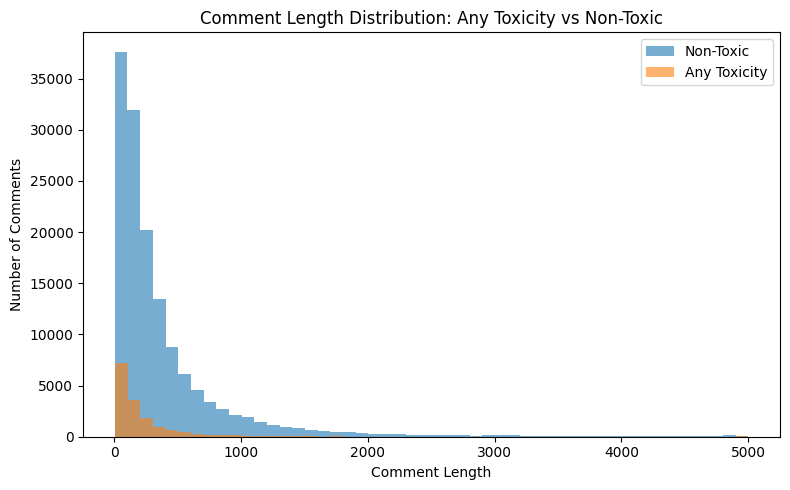

In [ ]:
# =========================
# 4. Comment Length Distribution: Any Toxicity vs Non-Toxic
# =========================

plt.figure(figsize=(8, 5))

plt.hist(new_data[new_data["any_toxic"] == 0]["comment_length"], bins=50, alpha=0.6, label="Non-Toxic")
plt.hist(new_data[new_data["any_toxic"] == 1]["comment_length"], bins=50, alpha=0.6, label="Any Toxicity")

#plt.xlim(0, 1000)  # clips extreme long comments only in the graph
plt.title("Comment Length Distribution: Any Toxicity vs Non-Toxic")
plt.xlabel("Comment Length")
plt.ylabel("Number of Comments")
plt.legend()
plt.tight_layout()
plt.show()

- Both distributions are heavily right-skewed and peak at very short comment lengths, meaning most comments, toxic or not, tend to be short
- The toxic distribution drops off much faster though; by around 500 characters it's nearly flat, while non-toxic comments spread further into longer lengths
- This confirms that very long comments are almost exclusively non-toxic, likely detailed Wikipedia edits or discussions
- The overlap at shorter lengths is heavy, which means length alone won't get the model far as a classifier — the two groups are just too mixed in that range
- **Modeling consideration:** `comment_length` may still contribute a small signal at the extremes (very long = likely non-toxic), but it will be a weak feature overall compared to lexical features

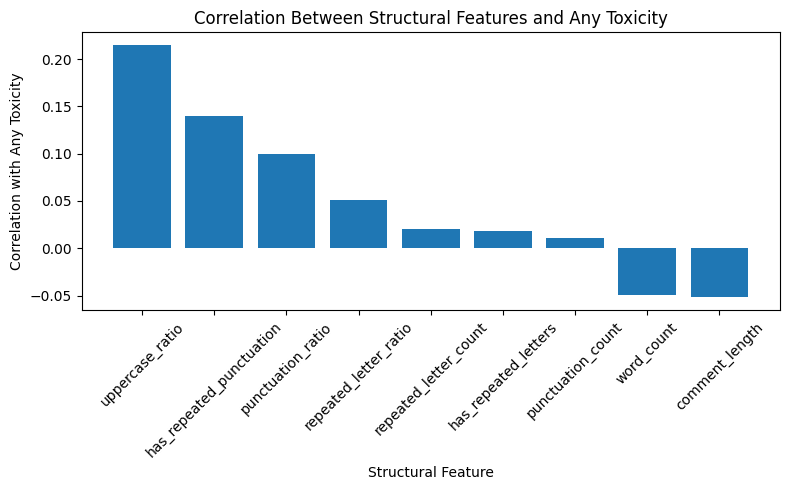

In [ ]:
# =========================
# 5. Structural Feature Correlation with Any Toxicity
# =========================

corr_with_any_toxic = (new_data[structure_cols + ["any_toxic"]].corr()["any_toxic"].drop("any_toxic").sort_values(ascending=False))

plt.figure(figsize=(8, 5))
plt.bar(corr_with_any_toxic.index, corr_with_any_toxic.values)
plt.title("Correlation Between Structural Features and Any Toxicity")
plt.xlabel("Structural Feature")
plt.ylabel("Correlation with Any toxicity type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



- All correlation values here are relatively small — even the highest ones (`uppercase_ratio`, `has_repeated_punctuation`) show only modest relationships with the toxicity label
- This doesn't mean these features are useless; it means their relationship with toxicity isn't linear or direct
- A comment can be entirely uppercase and non-toxic (an excited sports fan), or entirely lowercase and deeply toxic — capitalization intensifies tone, it doesn't define content
- Structural features seem to act more like stylistic amplifiers than toxicity signals in their own right
- The main takeaway: structural features are unlikely to carry any model on their own
- **Modeling consideration:** Will not drop low-correlation features prematurely, even weak linear correlations can add value in a logistic regression when combined with other features. That said, the structural-only model is expected to underperform significantly here, which makes it a useful baseline for quantifying exactly how much lexical features contribute over structure alone

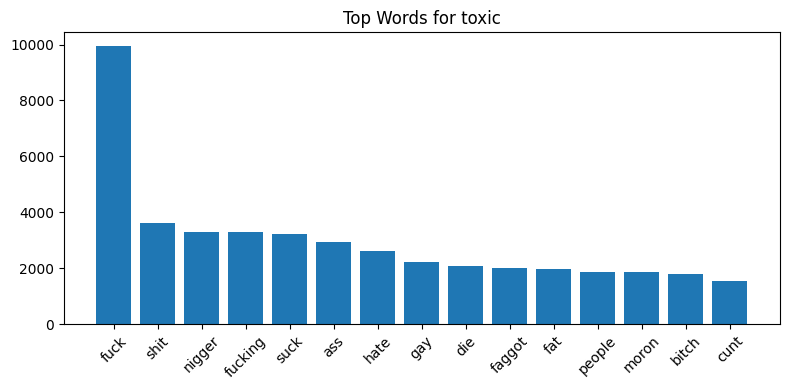

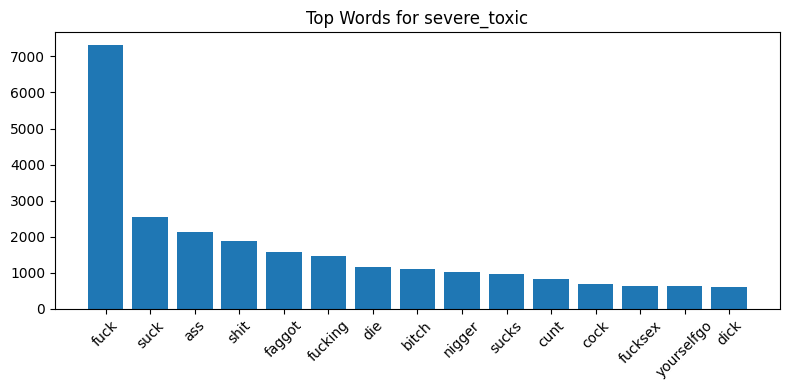

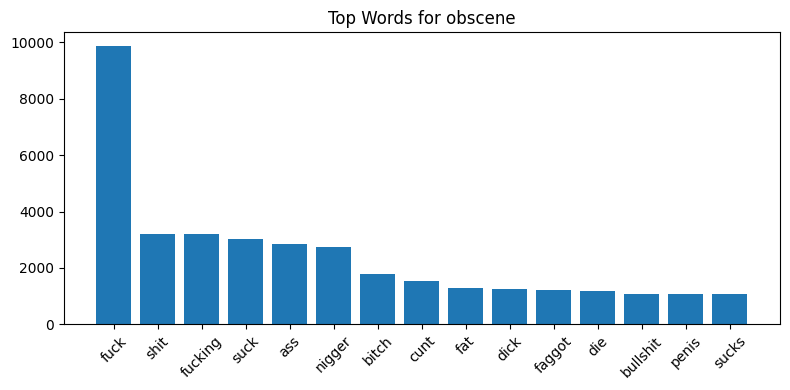

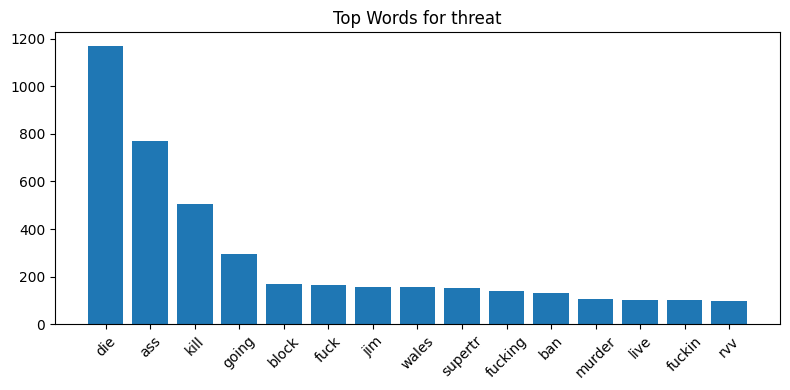

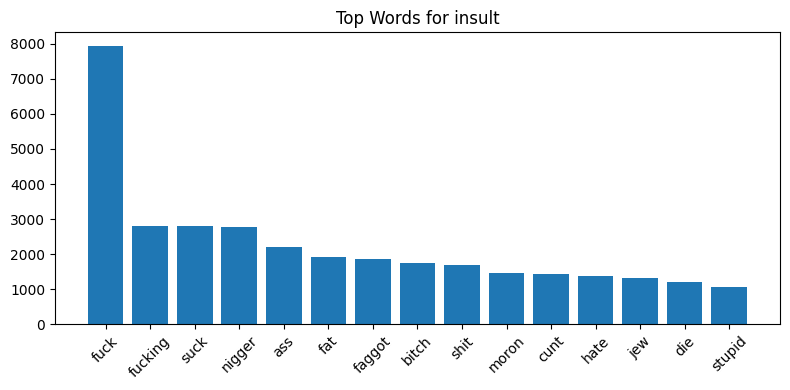

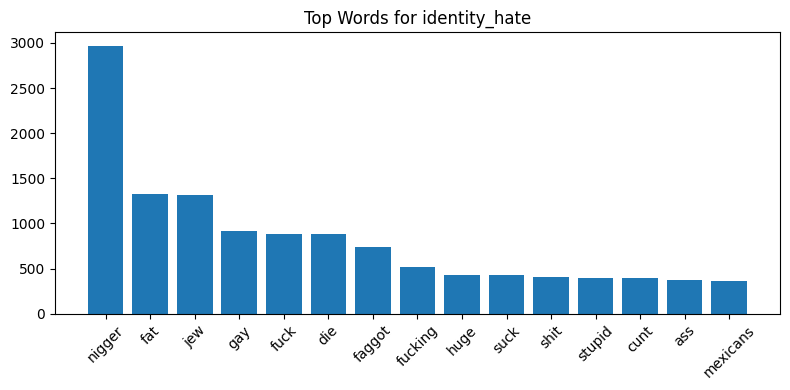

In [ ]:
# =========================
# 6. Most Common Words per Toxicity Type
# =========================

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from collections import Counter

label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
#added words that might be common on wikipedia page as the dataset is of wikipedia
custom_stopwords = set(ENGLISH_STOP_WORDS).union({
    "article", "page", "wikipedia", "edit", "talk", "would", "one", "like",
    "get", "also", "know", "think", "really", "just", "don", "doesn", "didn",
    "isn", "aren", "can", "could", "wiki"
})

def get_meaningful_words(text_series):
    words = []

    for text in text_series:
        text = str(text).lower()
        text = re.sub(r"[^a-zA-Z\s]", " ", text)

        for word in text.split():
            if word not in custom_stopwords and len(word) > 2:
                words.append(word)

    return words

# Store results
top_words_per_label = {}

for label in label_cols:
    words = get_meaningful_words(data[data[label] == 1]["clean_text"])
    word_counts = Counter(words).most_common(15)

    df_words = pd.DataFrame(word_counts, columns=["word", "count"])
    top_words_per_label[label] = df_words

    # Plot
    plt.figure(figsize=(8, 4))
    plt.bar(df_words["word"], df_words["count"])
    plt.title(f"Top Words for {label}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


- `toxic`, `severe_toxic`, `obscene`, and `insult` share heavy overlap in their top words — the same profanities and slurs appear across all four
- `threat` breaks clearly from this pattern — its top words are more action-oriented and conditional, reinforcing the earlier observation that threatening language operates differently from profanity-driven toxicity
- `identity_hate` is also clearly distinct, dominated by group-identifying terms — which suggests hate speech might actually be more lexically tractable than some of the blurrier subtypes
- These are raw counts though, not weighted by how discriminating each word is — a word appearing 500 times in toxic comments but 10,000 times in non-toxic ones carries almost no real signal, which is exactly the problem TF-IDF is there to fix
- **Modeling consideration:** Use bigrams (`ngram_range=(1,2)`) in TF-IDF — phrases like "kill yourself" or "go back" carry meaning that unigrams alone would miss. Given that `threat` and `identity_hate` rely on structurally different vocabulary, their classifiers may benefit from a higher `max_features` cap to ensure enough of their distinctive terms are retained in the feature space

In [ ]:
# =========================
# 7. Average Structural Features by Each Toxicity Type
# =========================

for label in label_cols:
    print(f"\nAverage structural features for {label}:")
    display(new_data.groupby(label)[structure_cols].mean())


Average structural features for toxic:


,comment_length,word_count,uppercase_ratio,punctuation_count,punctuation_ratio,has_repeated_punctuation,has_repeated_letters,repeated_letter_count,repeated_letter_ratio
toxic,,,,,,,,,
0,401.372039,68.971054,0.060511,8.991911,0.027025,0.027636,0.030921,0.052111,0.000157
1,292.475481,51.289787,0.154026,9.966457,0.035858,0.116320,0.041650,0.160390,0.000502



Average structural features for severe_toxic:


,comment_length,word_count,uppercase_ratio,punctuation_count,punctuation_ratio,has_repeated_punctuation,has_repeated_letters,repeated_letter_count,repeated_letter_ratio
severe_toxic,,,,,,,,,
0,390.344739,67.192076,0.067360,8.942204,0.027745,0.034899,0.031930,0.055891,0.000185
1,449.339185,75.620690,0.278934,23.259561,0.040372,0.158621,0.033856,0.715987,0.000621



Average structural features for obscene:


...

,comment_length,word_count,uppercase_ratio,punctuation_count,punctuation_ratio,has_repeated_punctuation,has_repeated_letters,repeated_letter_count,repeated_letter_ratio
threat,,,,,,,,,
0,391.191928,67.312718,0.069090,9.039714,0.027847,0.035805,0.031939,0.062476,0.000189
1,305.240586,55.165272,0.197321,24.263598,0.035975,0.146444,0.035565,0.066946,0.000322



Average structural features for insult:


,comment_length,word_count,uppercase_ratio,punctuation_count,punctuation_ratio,has_repeated_punctuation,has_repeated_letters,repeated_letter_count,repeated_letter_ratio
insult,,,,,,,,,
0,396.962376,68.263352,0.064662,9.068173,0.027423,0.031928,0.031703,0.056781,0.000175
1,274.854894,48.269265,0.162148,9.415514,0.036513,0.117177,0.036689,0.172401,0.000477



Average structural features for identity_hate:


,comment_length,word_count,uppercase_ratio,punctuation_count,punctuation_ratio,has_repeated_punctuation,has_repeated_letters,repeated_letter_count,repeated_letter_ratio
identity_hate,,,,,,,,,
0,391.690432,67.411908,0.068426,9.096858,0.027824,0.035319,0.031791,0.06221,0.000186
1,305.834164,52.014235,0.187538,7.786477,0.033265,0.128114,0.049822,0.09395,0.000606


- The differences in means between toxic and non/other-toxic groups exist but are modest across the board
- `uppercase_ratio` is the most consistent signal, trending higher across almost every toxic subtype
- `comment_length` is inconsistent — most subtypes skew shorter, but `severe_toxic` actually reverses this and skews longer
- Repeated-letter and punctuation features show the smallest differences, hinting early that these will be the weakest contributors in the model
- **Modeling consideration:** Standardize all structural features before feeding them into logistic regression — the scale differences between `comment_length` (hundreds) and `uppercase_ratio` (0 to 1) will distort coefficient magnitudes otherwise

## Initial EDA Summary
Across the graphs and tables above, a few consistent themes emerge. The dataset is structurally challenging: heavily imbalanced toward non-toxic comments, and even within the toxic portion, the rarest subtypes — `threat`, `severe_toxic`, and `identity_hate` — are the ones most likely to slip through a poorly calibrated model. The toxicity labels are also far from independent: `insult`, `obscene`, and `toxic` share significant lexical overlap, meaning a feature set that catches one tends to catch the others, while `threat` stands apart as a linguistically distinct category that will likely require different signals to detect reliably. Structural features like capitalization, punctuation, and comment length do vary between toxic and non-toxic comments, but the differences are modest and inconsistent across subtypes — `uppercase_ratio` is the most stable structural signal, yet even it doesn't hold uniformly across all labels. What the EDA ultimately points to is that word choice will do the heavy lifting in any toxicity classifier, structural features may contribute marginal supporting signals at best, and evaluation needs to go well beyond accuracy given how skewed the class distribution is.

# **Model Building**

In [ ]:
#Import the necessary functions
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, average_precision_score

#Initiate the containers
lexical_models = {}
structural_models = {}
combined_models = {}

tfidf_objects = {}
scaler_objects = {}

results = []
reports = {}

#Initialize the columns
label_cols = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

structure_cols = [
    "comment_length",
    "word_count",
    "uppercase_ratio",
    "punctuation_count",
    "punctuation_ratio",
    "has_repeated_punctuation",
    "has_repeated_letters",
    "repeated_letter_count",
    "repeated_letter_ratio",
]

In [ ]:
#Model Implementation
model_data = new_data.copy()

for label in label_cols:

    print("\n" + "=" * 60)
    print("Training models for:", label)
    print("=" * 60)

    y = model_data[label]
    indices = np.arange(model_data.shape[0])

    #Transform comments into numerical values using TF-IDF
    tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2), #2-grams should suffice to capture most toxic word combinations
    stop_words = None, #Keep the English stop words as we are doing comment analysis and stopwords could matter
    sublinear_tf=False #Repetitions do matter
    )

    #Initialize the StandardScaler
    scaler = StandardScaler()

    #Split the data now to prevent leakage
    train_idx, test_idx, y_train, y_test = train_test_split(
        indices,
        y,
        test_size=0.2,
        random_state=2026,
        stratify=y #maintains the ratio of positives and negatives for rarer toxicity labels
    )

    #Apply TF-IDF on the word content
    X_train_text = tfidf.fit_transform(model_data.iloc[train_idx]["clean_text"])
    X_test_text = tfidf.transform(model_data.iloc[test_idx]["clean_text"])

    #Standardize the lexical structure features
    X_train_struct = scaler.fit_transform(model_data.iloc[train_idx][structure_cols])
    X_test_struct = scaler.transform(model_data.iloc[test_idx][structure_cols])

    #TF-IDF creates sparse matrices, so, to combine, structural features also need to be converted
    X_train_struct_sparse = csr_matrix(X_train_struct)
    X_test_struct_sparse = csr_matrix(X_test_struct)

    # Combined features: word choice + structure
    X_train_combined = hstack([X_train_text, X_train_struct_sparse])
    X_test_combined = hstack([X_test_text, X_test_struct_sparse])

    # Model 1: lexical only
    lexical_model = LogisticRegression(max_iter=1000, class_weight="balanced") #class_weight is balanced to pay attention to minority classes
    lexical_model.fit(X_train_text, y_train)
    y_pred_lexical = lexical_model.predict(X_test_text)
    y_score_lexical = lexical_model.predict_proba(X_test_text)[:, 1] #Probability of class 1

    # Model 2: structural only
    structural_model = LogisticRegression(max_iter=1000, class_weight="balanced")
    structural_model.fit(X_train_struct, y_train)
    y_pred_structural = structural_model.predict(X_test_struct)
    y_score_structural = structural_model.predict_proba(X_test_struct)[:, 1]

    # Model 3: combined
    combined_model = LogisticRegression(max_iter=1000, class_weight="balanced")
    combined_model.fit(X_train_combined, y_train)
    y_pred_combined = combined_model.predict(X_test_combined)
    y_score_combined = combined_model.predict_proba(X_test_combined)[:, 1]

    lexical_models[label] = lexical_model
    structural_models[label] = structural_model
    combined_models[label] = combined_model
    tfidf_objects[label] = tfidf
    scaler_objects[label] = scaler

    reports[(label, "lexical_only")] = classification_report(y_test, y_pred_lexical, zero_division=0)
    reports[(label, "structural_only")] = classification_report(y_test, y_pred_structural, zero_division=0)
    reports[(label, "combined")] = classification_report(y_test, y_pred_combined, zero_division=0)

    results.append({
        "label": label,
        "model_type": "lexical_only",
        "precision": precision_score(y_test, y_pred_lexical, zero_division=0),
        "recall": recall_score(y_test, y_pred_lexical, zero_division=0),
        "f1": f1_score(y_test, y_pred_lexical, zero_division=0),
        "average_precision": average_precision_score(y_test, y_score_lexical)
    })

    results.append({
        "label": label,
        "model_type": "structural_only",
        "precision": precision_score(y_test, y_pred_structural, zero_division=0),
        "recall": recall_score(y_test, y_pred_structural, zero_division=0),
        "f1": f1_score(y_test, y_pred_structural, zero_division=0),
        "average_precision": average_precision_score(y_test, y_score_structural)
    })

    results.append({
        "label": label,
        "model_type": "combined",
        "precision": precision_score(y_test, y_pred_combined, zero_division=0),
        "recall": recall_score(y_test, y_pred_combined, zero_division=0),
        "f1": f1_score(y_test, y_pred_combined, zero_division=0),
        "average_precision": average_precision_score(y_test, y_score_combined)
    })



Training models for: toxic

Training models for: severe_toxic

Training models for: obscene

Training models for: threat

Training models for: insult

Training models for: identity_hate


# **Model Evaluation**

In [ ]:
# Create results dataframe
results_df = pd.DataFrame(results)

results_df

,label,model_type,precision,recall,f1,average_precision
0,toxic,lexical_only,0.540249,0.851259,0.660998,0.821751
1,toxic,structural_only,0.182990,0.357306,0.242028,0.232528
2,toxic,combined,0.555081,0.849951,0.671574,0.826946
3,severe_toxic,lexical_only,0.220893,0.868339,0.352193,0.418375
4,severe_toxic,structural_only,0.047553,0.429467,0.085625,0.082754
5,severe_toxic,combined,0.236240,0.874608,0.372000,0.451209
6,obscene,lexical_only,0.552760,0.871006,0.676315,0.832464
7,obscene,structural_only,0.111605,0.371598,0.171655,0.145241
8,obscene,combined,0.555388,0.872189,0.678637,0.832500
9,threat,lexical_only,0.176856,0.843750,0.292419,0.457552


In [ ]:
#Look at best models based on f1-score
best_models = results_df.loc[
    results_df.groupby("label")["f1"].idxmax()
].sort_values("label")

best_models

,label,model_type,precision,recall,f1,average_precision
17,identity_hate,combined,0.152613,0.779359,0.255245,0.365440
14,insult,combined,0.435800,0.874921,0.581803,0.735328
8,obscene,combined,0.555388,0.872189,0.678637,0.832500
5,severe_toxic,combined,0.236240,0.874608,0.372000,0.451209
11,threat,combined,0.192037,0.854167,0.313576,0.448693
2,toxic,combined,0.555081,0.849951,0.671574,0.826946


In [ ]:
# Compare F1 scores across model types
f1_table = results_df.pivot(
    index="label",
    columns="model_type",
    values="f1"
)

f1_table

model_type,combined,lexical_only,structural_only
label,,,
identity_hate,0.255245,0.254755,0.045187
insult,0.581803,0.578537,0.163980
obscene,0.678637,0.676315,0.171655
severe_toxic,0.372000,0.352193,0.085625
threat,0.313576,0.292419,0.015818
toxic,0.671574,0.660998,0.242028


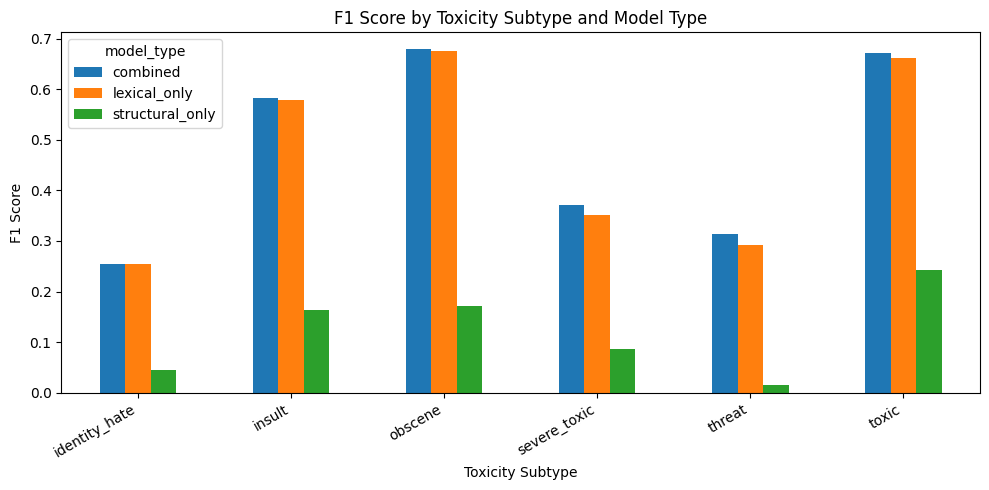

In [ ]:
#Visualize how F1 Scores differes by toxicity subtype and model type
f1_table.plot(kind="bar", figsize=(10, 5))
plt.title("F1 Score by Toxicity Subtype and Model Type")
plt.ylabel("F1 Score")
plt.xlabel("Toxicity Subtype")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# Compare average precision / PR-AUC across model types
pr_auc_table = results_df.pivot(
    index="label",
    columns="model_type",
    values="average_precision"
)

pr_auc_table

model_type,combined,lexical_only,structural_only
label,,,
identity_hate,0.365440,0.362669,0.037086
insult,0.735328,0.737724,0.124181
obscene,0.832500,0.832464,0.145241
severe_toxic,0.451209,0.418375,0.082754
threat,0.448693,0.457552,0.010721
toxic,0.826946,0.821751,0.232528


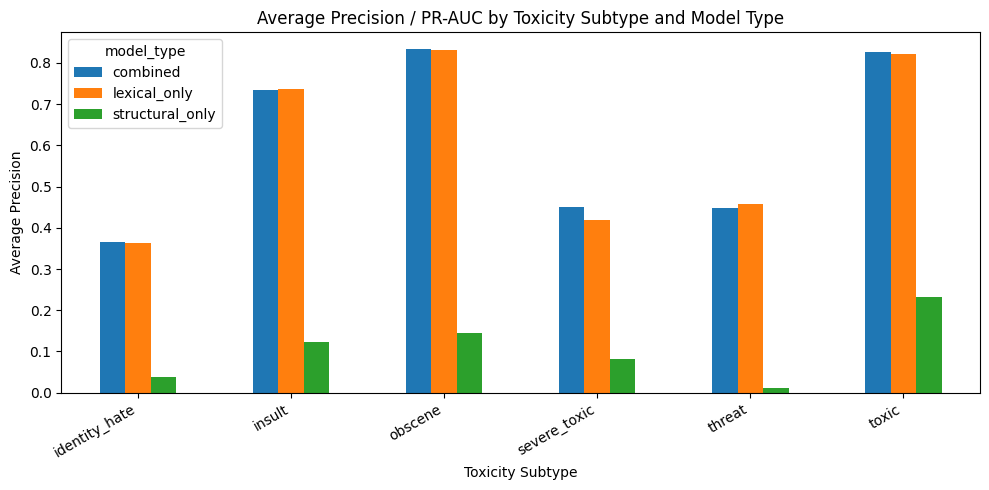

In [ ]:
#Visualize how PR-AUC differs by toxicity subtype and model type
pr_auc_table.plot(kind="bar", figsize=(10, 5))
plt.title("Average Precision / PR-AUC by Toxicity Subtype and Model Type")
plt.ylabel("Average Precision")
plt.xlabel("Toxicity Subtype")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
#Look at the classification report
for _, row in best_models.iterrows():
    label = row["label"]
    model_type = row["model_type"]

    print("\n" + "=" * 60)
    print("Best model for:", label)
    print("Model type:", model_type)
    print("=" * 60)

    print(reports[(label, model_type)])


Best model for: identity_hate
Model type: combined
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     31632
           1       0.15      0.78      0.26       281

    accuracy                           0.96     31913
   macro avg       0.58      0.87      0.62     31913
weighted avg       0.99      0.96      0.97     31913


Best model for: insult
Model type: combined
              precision    recall  f1-score   support

           0       0.99      0.94      0.97     30338
           1       0.44      0.87      0.58      1575

    accuracy                           0.94     31913
   macro avg       0.71      0.91      0.77     31913
weighted avg       0.97      0.94      0.95     31913


Best model for: obscene
Model type: combined
              precision    recall  f1-score   support

           0       0.99      0.96      0.98     30223
           1       0.56      0.87      0.68      1690

    accuracy                           

In terms of model evaluation, F1-score is used as the main metric for selecting the best model. Since the dataset is highly unbalanced, PR-AUC is reported as a complementary metric, and its results support the conclusion that combined models tend to perform the best, closely followed by lexical-only models. Thus, it is shown that word choice provides a moderate or strong signal for toxicity, while structural features are much less powerful. It is also worth noting that combining lexical and structural features leads to only a meagre improvement in terms of model performance compared to solely using lexical-only models.


Other than that, it is also worth noting that recall for these models are consistently much higher than precision. By setting class_weight to balanced, the models are more inclined to catch rarer toxic labels which makes it very capable of catching actual toxic comments, but the trade-off is that it also makes many false-positive predictions.



# **Structural Features Coefficient Evaluation**

In [ ]:
#We look at the importance of structural features using to the combined model
#to deduce which structural features still matter after word choices are included

top_structural_features = {}

for label in label_cols:
    coefficients = combined_models[label].coef_[0]

    # Structural features were added at the end of the combined feature matrix
    structural_coefficients = coefficients[-len(structure_cols):]

    structural_df = pd.DataFrame({
        "feature": structure_cols,
        "coefficient": structural_coefficients
    })

    structural_df["abs_coefficient"] = structural_df["coefficient"].abs()

    top_3 = structural_df.sort_values(
        "abs_coefficient",
        ascending=False
    ).head(3)

    top_structural_features[label] = top_3

    print("\nTop 3 structural features for:", label)
    display(top_3[["feature", "coefficient", "abs_coefficient"]])



Top 3 structural features for: toxic


,feature,coefficient,abs_coefficient
0,comment_length,0.340087,0.340087
2,uppercase_ratio,0.260659,0.260659
1,word_count,-0.175963,0.175963



Top 3 structural features for: severe_toxic


,feature,coefficient,abs_coefficient
0,comment_length,0.647623,0.647623
2,uppercase_ratio,0.227100,0.227100
5,has_repeated_punctuation,0.185980,0.185980



Top 3 structural features for: obscene


...

,feature,coefficient,abs_coefficient
0,comment_length,0.323687,0.323687
1,word_count,-0.276779,0.276779
5,has_repeated_punctuation,0.217257,0.217257



Top 3 structural features for: insult


,feature,coefficient,abs_coefficient
0,comment_length,0.305113,0.305113
1,word_count,-0.181997,0.181997
2,uppercase_ratio,0.144483,0.144483



Top 3 structural features for: identity_hate


,feature,coefficient,abs_coefficient
7,repeated_letter_count,-0.321335,0.321335
0,comment_length,0.214055,0.214055
2,uppercase_ratio,0.161321,0.161321


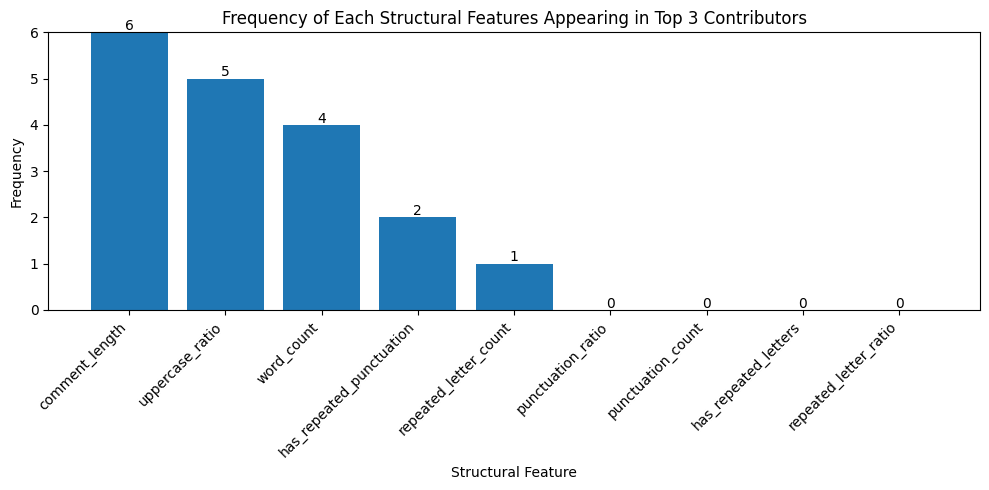

In [ ]:
#Plot frequency of structural features appearing in the top 3
top_feature_list = []

for label, df in top_structural_features.items():
    for feature in df["feature"]:
        top_feature_list.append(feature)

top_feature_counts = (
    pd.Series(top_feature_list)
    .value_counts()
    .reindex(structure_cols, fill_value=0)
    .sort_values(ascending=False)
)

top_feature_counts

plt.figure(figsize=(10, 5))

plt.bar(top_feature_counts.index, top_feature_counts.values)

plt.title("Frequency of Each Structural Features Appearing in Top 3 Contributors")
plt.xlabel("Structural Feature")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, len(label_cols))

for i, value in enumerate(top_feature_counts.values):
    plt.text(i, value + 0.05, str(value), ha="center")

plt.tight_layout()
plt.show()

Although the structural-only models are all relatively weak in terms of being able to provide signals for toxicity distinction, it is still valuable to look at what features exactly are contributing as supporting signals. Based on the results, it is clear that comment length, uppercase ratio, and word count appear the most consistently as top three structural contributors. The presence of repeated punctuation and the number of repeated letters do make appearances, but at a lower frequency.


In [ ]:
# Check skewness of numeric structural features
new_data[["comment_length", "uppercase_ratio"]].skew()

,0
comment_length,4.122748
uppercase_ratio,5.846841


In [ ]:
#Do stroing structural features differ across toxicity subtypes?
#Use Mann-Whitney U Tests
from scipy.stats import mannwhitneyu

numeric_test_features = ["comment_length", "uppercase_ratio"]

mannwhitney_results = []

for label in label_cols:
    for feature in numeric_test_features:
        positive_group = new_data[new_data[label] == 1][feature]
        negative_group = new_data[new_data[label] == 0][feature]

        #Perform the test
        stat, p_value = mannwhitneyu(
            positive_group,
            negative_group,
            alternative="two-sided"
        )

        #Store the results
        mannwhitney_results.append({
            "label": label,
            "feature": feature,
            "positive_mean": positive_group.mean(),
            "negative_mean": negative_group.mean(),
            "difference": positive_group.mean() - negative_group.mean(),
            "p_value": p_value
        })

mannwhitney_results = pd.DataFrame(mannwhitney_results)

mannwhitney_results


,label,feature,positive_mean,negative_mean,difference,p_value
0,toxic,comment_length,292.475481,401.372039,-108.896558,0.000000e+00
1,toxic,uppercase_ratio,0.154026,0.060511,0.093514,3.745356e-79
2,severe_toxic,comment_length,449.339185,390.344739,58.994446,3.780941e-102
3,severe_toxic,uppercase_ratio,0.278934,0.067360,0.211574,1.281387e-37
4,obscene,comment_length,284.166174,396.903974,-112.737800,0.000000e+00
5,obscene,uppercase_ratio,0.165901,0.064083,0.101818,3.246357e-55
6,threat,comment_length,305.240586,391.191928,-85.951342,6.589533e-21
7,threat,uppercase_ratio,0.197321,0.069090,0.128231,3.563389e-03
8,insult,comment_length,274.854894,396.962376,-122.107482,0.000000e+00
9,insult,uppercase_ratio,0.162148,0.064662,0.097486,3.720396e-41


In [ ]:
#Does the weak structural feature show weaker or less consistent differences?
#Use Chi-Square Test
from scipy.stats import chi2_contingency

chi_square_results = []

for label in label_cols:
    table = pd.crosstab(new_data["has_repeated_letters"], new_data[label])

    chi2, p_value, dof, expected = chi2_contingency(table)

    chi_square_results.append({
        "label": label,
        "feature": "has_repeated_letters",
        "chi2": chi2,
        "p_value": p_value
    })

chi_square_results = pd.DataFrame(chi_square_results)

chi_square_results


,label,feature,chi2,p_value
0,toxic,has_repeated_letters,51.120632,8.686052e-13
1,severe_toxic,has_repeated_letters,0.132148,7.162154e-01
2,obscene,has_repeated_letters,12.027582,5.241903e-04
3,threat,has_repeated_letters,0.102326,7.490560e-01
4,insult,has_repeated_letters,5.857927,1.550705e-02
5,identity_hate,has_repeated_letters,14.062273,1.768559e-04


## Statistical Test Results

To support the structural feature analysis, I tested whether selected structural features differ by toxicity subtype. `comment_length` and `uppercase_ratio` were chosen because they appeared frequently among the top structural contributors in the combined model. On the other hand, `has_repeated_letters` was selected because it appeared less often in the top three, making it useful as a weaker comparison feature.

For `comment_length` and `uppercase_ratio`, Mann-Whitney U tests were used because these variables are numeric and their distributions are skewed. For `has_repeated_letters`, chi-square tests were used because the variable is binary.

The Mann-Whitney U results show that `uppercase_ratio` is significantly higher for every toxicity subtype compared with comments without that label. This suggests that uppercase usage is a general structural marker of toxicity. With that said, because the pattern appears across all subtypes, it is less useful for distinguishing between specific toxicity categories. In other words, uppercase ratio may help separate toxic from non-toxic comments, but it does not appear to be strongly subtype-specific.

The results for `comment_length` are more mixed. Comments labeled `toxic`, `obscene`, `threat`, `insult`, and `identity_hate` are shorter on average than comments without those labels, but `severe_toxic` comments are different in that they are longer on average. This suggests that comment length may be more useful for distinguishing `severe_toxic` from other toxicity categories than for identifying toxicity in general.

The chi-square results for `has_repeated_letters` are weaker and less consistent than the results for `comment_length` and `uppercase_ratio`. Repeated letters show a statistically significant association with `toxic`, `obscene`, and `identity_hate`, but not with `severe_toxic`, `threat`, or `insult`. This suggests that repeated letters may capture some stylistic emphasis in certain toxic comments, but they are not a reliable structural signal across toxicity subtypes. This matches the model results, where repeated-letter features appeared less often among the top structural contributors.

Overall, these analyses indicate that lexical features are better at distinguishing between toxicity subtypes, while structural features provide broader supporting signals. Word choice is the main driver of subtype classification, whereas features such as capitalization, comment length, and punctuation mainly help capture general patterns of toxic writing style.



# **Insights, Conclusions, Recommendations**

## Summary of Insights


 To begin, the dataset is highly unbalanced as most comments are non-toxic, composing 89.83% of the entire dataset. Among the toxic comments, some toxicity subtypes are also much rarer than others, especially `threat`, `severe_toxic`, and `identity_hate`. This means that, in terms of model evaluation, accuracy alone is not a useful evaluation metric because a model could perform well on accuracy by mostly predicting non-toxic comments.


INSIGHT FROM EDA


The modeling results show that lexical-only and combined models perform much better than structural-only models. This suggests that word choice is the strongest signal for detecting toxicity, while structural features are much less reliable. Furthermore, the combined model performs only slightly better than the lexical-only model for most toxicity subtypes based on F1-score and PR-AUC. This suggests that structural features does provide some supportive information, but the added benefit is meagre in magnitude.The only aberrations to this trend are'insult comments and threat comments, whose combined models actually perform just slightly worse than lexical-only models by PR-AUC. Though the difference is negligeable, this does hint at the possibility that the inclusion of structural features could sometimes cause more harm than good.


Analysis of the structural features reveals that, among all the selected structural features, comment length, uppercase ratio, and word count appear most consistently among the top structural contributors. Though the presence of repeated punctuation and the prevalence of repeated letters does make rare appearances in the top three, the results suggest that they provide much weaker signals.


## Conclusion


Overall, the project shows that lexical features, compared to structural ones, are the most important ones that carry the strongest signal for identifying toxicity subtypes. By themselves structural features create much weaker models, and they barely improve model performance when combined with lexical features.


Therefore, the best approach is to limit the weight of comment length, uppercase ratio and word count - structural features with the strongest signals - to instead focus on word-based features when it comes to detecting toxic comments of various subtypes.


## Recommendations


Based on these findings, moderation systems should, in the future, prioritize lexical features such as words and phrases when identifying toxic comments of different subtypes. TF-IDF features with unigrams and bigrams are useful because they capture both individual toxic words and short toxic phrases.


Structural features do provide some supporting signals, but they are much less useful and should never be used alone. In fact, it is often not worth the effort to combine them with lexical features as the overall improvement to model performance is barely noticeable. Based on these findings, features such as punctuation ratio, punctuation count, repeated letter ratio and the presence of repeated letters should rarely be included in models, as, even among structural features, they provide little value in terms of  detecting patterns of aggressive or intensified language.


In most comment datasets, it would not be surprising to find that a great majority of comments are in fact non-toxic. This means that future models should avoid relying on accuracy as the main metric and should instead turn to f1-score and PR-AUC as evaluation metrics.


Finally, future investigation should focus on 'identity_hate', 'severe_toxic' and 'threat' comments as even the best performing models have f1-scores  below 0.4 and average precisions below 0.5. These labels definitely require more attention as they are extremely rare even among toxic comments, which makes detecting difficult. More work could be done on collecting more examples of rare toxicity types, tuning decision thresholds, or using more advanced text models to better capture context and spot these types of comments when present.




# **MODEL DEMO**

In [ ]:
def classify_comment():
    print("\nToxicity Classifier — type 'quit' to exit\n")

    while True:
        comment = input("Enter a comment: ").strip()

        if comment.lower() == "quit":
            print("Exiting.")
            break

        if not comment:
            print("Please enter a comment.\n")
            continue

        cleaned = clean_text(comment)
        temp_df = pd.DataFrame({"clean_text": [cleaned]})
        temp_df = add_structural_features(temp_df)

        results = {}
        for label in label_cols:
            X_text = tfidf_objects[label].transform([cleaned])
            X_struct = scaler_objects[label].transform(temp_df[structure_cols])
            X_struct_sparse = csr_matrix(X_struct)
            X_combined = hstack([X_text, X_struct_sparse])
            prob = combined_models[label].predict_proba(X_combined)[0][1]
            results[label] = prob

        any_toxic = any(prob >= 0.5 for prob in results.values())

        print("\n🌹 Non-Toxic\n" if not any_toxic else "\n🥀 Toxic — flagged categories:\n")
        for label, prob in results.items():
            bar = "█" * int(prob * 20)
            flag = " ← flagged" if prob >= 0.7 else ""
            print(f"  {label:<15} {prob:.2f}  {bar}{flag}")
        print()

classify_comment()